# ResumeAI — Production-Grade Resume-Job Matching System

## What's Different in This Notebook

| Improvement | Previous | This Notebook |
|-------------|----------|--------------|
| **Training data** | 500 pairs from 200 JDs | 815 pairs from 305 JDs (62% more unique JDs) |
| **Loss function** | CoSENTLoss only (ranking) | Combined CoSENTLoss + CosineSimilarityLoss (ranking + calibration) |
| **Calibration** | Isotonic regression on internal val | Platt scaling on external calibration split |
| **Strong match distribution** | 101 (20%) | 206 (25%) — addresses underscoring |
| **Hard negatives** | 71 (14%) | 141 (17%) — maintains discrimination strength |
| **External evaluation** | 212 pairs from unseen JDs | Same 212, split: 106 calibration + 106 final test |
| **Models** | Separate experiments | All models in one pipeline with fair comparison |

**Models trained:**
- **MPNet** bi-encoder with combined loss + Platt calibration
- **RoBERTa** cross-encoder with augmented data + weight decay
- **DistilRoBERTa** cross-encoder (smaller, regularized)
- **Hybrid** (MPNet filter + best cross-encoder re-rank)

**Runtime:** T4 GPU, ~60-75 minutes total.


---
## 1. Setup

In [1]:
!pip install -q sentence-transformers datasets pandas scikit-learn matplotlib

import torch, time, json, pickle, warnings, re, random, copy
import numpy as np
import pandas as pd
warnings.filterwarnings('ignore')

from collections import Counter
from torch.utils.data import DataLoader
from sklearn.model_selection import train_test_split
from sklearn.metrics.pairwise import cosine_similarity
from sklearn.isotonic import IsotonicRegression
from sklearn.linear_model import LogisticRegression
from scipy.stats import spearmanr
from scipy.optimize import minimize_scalar

from sentence_transformers import SentenceTransformer, InputExample, losses
from sentence_transformers.evaluation import EmbeddingSimilarityEvaluator
from sentence_transformers.cross_encoder import CrossEncoder
from sentence_transformers.cross_encoder.evaluation import CECorrelationEvaluator

print(f"PyTorch: {torch.__version__}")
print(f"CUDA: {torch.cuda.is_available()}")
if torch.cuda.is_available():
    print(f"GPU: {torch.cuda.get_device_name(0)} ({torch.cuda.get_device_properties(0).total_memory/1e9:.1f} GB)")


PyTorch: 2.10.0+cu128
CUDA: True
GPU: Tesla T4 (15.6 GB)


---
## 2. Load Data

Upload two files:
1. `resume_jd_training_800.csv` — 815 training pairs from 305 unique JDs
2. `external_test_200_pairs.csv` — 212 test pairs from 53 completely unseen JDs

The external test set is split into two halves:
- **106 pairs for calibration** — teaches Platt scaling how to map scores on unseen JDs
- **106 pairs for final evaluation** — completely untouched, the number you report


In [3]:
from google.colab import files

print("Upload TRAINING data (resume_jd_training_800.csv):")
up1 = files.upload()
df = pd.read_csv(list(up1.keys())[0])
print(f"✅ Training: {len(df)} pairs from {df['source'].nunique() if 'source' in df.columns else '?'} sources")

print("\nUpload EXTERNAL TEST data (external_test_200_pairs.csv):")
up2 = files.upload()
ext_full = pd.read_csv(list(up2.keys())[0])
print(f"✅ External: {len(ext_full)} pairs")

# Split external into calibration (106) and final test (106)
# Stratified so both halves have same match type distribution
ext_cal, ext_test = train_test_split(ext_full, test_size=0.5, random_state=42, stratify=ext_full['match_type'])

print(f"\nExternal calibration: {len(ext_cal)} pairs (for Platt scaling)")
print(f"External final test:  {len(ext_test)} pairs (for reporting)")

print(f"\nTraining distribution: {dict(Counter(df['match_type']))}")
print(f"Calibration distribution: {dict(Counter(ext_cal['match_type']))}")
print(f"Final test distribution: {dict(Counter(ext_test['match_type']))}")


Upload TRAINING data (resume_jd_training_800.csv):


Saving resume_jd_training_800.csv to resume_jd_training_800 (1).csv
✅ Training: 815 pairs from 2 sources

Upload EXTERNAL TEST data (external_test_200_pairs.csv):


Saving external_test_200_pairs.csv to external_test_200_pairs.csv
✅ External: 212 pairs

External calibration: 106 pairs (for Platt scaling)
External final test:  106 pairs (for reporting)

Training distribution: {'partial': 163, 'hard_negative': 141, 'weak': 105, 'good': 200, 'strong': 206}
Calibration distribution: {'good': 13, 'hard_negative': 27, 'strong': 26, 'weak': 27, 'partial': 13}
Final test distribution: {'partial': 13, 'strong': 27, 'good': 14, 'weak': 26, 'hard_negative': 26}


---
## 3. Smart Truncation + Data Augmentation


In [4]:
# ── Smart truncation ──
def smart_truncate_jd(jd_text, max_words=350):
    boilerplate = [r'equal opportunity employer.*', r'does not discriminate.*',
        r'reasonable accommodation.*', r'(compensation|salary|pay) range.*',
        r'(what we offer|our benefits|perks and benefits|benefits:).*']
    cleaned = jd_text
    for p in boilerplate:
        cleaned = re.split(p, cleaned, flags=re.IGNORECASE)[0]
    req = [r'(requirements?|qualifications?|what you.?ll need|must have)',
           r'(responsibilities|what you.?ll do|in this role|you will)']
    best = 0
    for p in req:
        m = re.search(p, cleaned, re.IGNORECASE)
        if m:
            s = max(0, m.start()-200)
            if best == 0 or s < best: best = s
    if best > 100:
        cleaned = cleaned[:100] + "\n" + cleaned[best:]
    words = cleaned.split()
    return ' '.join(words[:max_words]).strip() if len(words) > max_words else cleaned.strip()

# Apply to all datasets
for d in [df, ext_cal, ext_test, ext_full]:
    d['jd_clean'] = d['jd'].apply(lambda x: smart_truncate_jd(x, 350))

print(f"JD lengths after cleaning:")
print(f"  Training: {df['jd_clean'].str.split().str.len().mean():.0f} avg words")
print(f"  External: {ext_full['jd_clean'].str.split().str.len().mean():.0f} avg words")

# ── Data augmentation ──
random.seed(42)

def shuffle_sections(text):
    sections = {}; curr = 'header'; lines = []
    for line in text.split('\n'):
        u = line.strip().upper()
        for kw, sec in [('SUMMARY','summary'),('SKILLS','skills'),('EXPERIENCE','experience'),('EDUCATION','education')]:
            if kw in u:
                sections[curr] = '\n'.join(lines); curr = sec; lines = [line]; break
        else:
            lines.append(line)
    sections[curr] = '\n'.join(lines)
    header = sections.get('header','')
    body = ['summary','skills','experience','education']
    random.shuffle(body)
    return (header + ''.join(sections.get(s,'') for s in body if s in sections)).strip()

def drop_sentences(text, rate=0.12):
    sents = re.split(r'(?<=[.!?])\s+|\n', text)
    if len(sents) <= 3: return text
    drop = set(random.sample(range(1,len(sents)), min(max(1,int(len(sents)*rate)), len(sents)-2)))
    return ' '.join(s for i,s in enumerate(sents) if i not in drop).strip()

def keyword_noise(text):
    reps = {'Python':'Python programming','JavaScript':'JS/JavaScript','React':'React.js',
            'AWS':'Amazon Web Services','SQL':'SQL databases','Docker':'Docker containers',
            '5+ years':'five or more years','3+ years':'three or more years'}
    r = text
    for k in random.sample(list(reps.keys()), min(2,len(reps))):
        if k in r: r = r.replace(k, reps[k], 1)
    return r

def augment_dataset(dataframe, n_aug=3):
    rows = []
    aug_types = ['shuffle','drop_jd','drop_resume','noise']
    for _, row in dataframe.iterrows():
        rows.append({'resume':row['resume'],'jd':row['jd_clean'],'score':row['score'],
                     'match_type':row['match_type'],'augmented':False})
        for aug in random.sample(aug_types, min(n_aug, len(aug_types))):
            r, j, s = row['resume'], row['jd_clean'], row['score']
            if aug == 'shuffle': r = shuffle_sections(r)
            elif aug == 'drop_jd': j = drop_sentences(j)
            elif aug == 'drop_resume': r = drop_sentences(r, 0.08)
            elif aug == 'noise': r = keyword_noise(r); j = keyword_noise(j)
            s_noisy = float(np.clip(s + np.random.uniform(-0.02, 0.02), 0.01, 0.99))
            rows.append({'resume':r,'jd':j,'score':s_noisy,'match_type':row['match_type'],'augmented':True})
    return pd.DataFrame(rows)


JD lengths after cleaning:
  Training: 344 avg words
  External: 346 avg words


---
## 4. Split and Augment

In [5]:
# Internal split for training
train_df, val_df = train_test_split(df, test_size=0.15, random_state=42, stratify=df['match_type'])
train_df = train_df.copy(); val_df = val_df.copy()
train_df['jd_clean'] = train_df['jd'].apply(lambda x: smart_truncate_jd(x, 350))
val_df['jd_clean'] = val_df['jd'].apply(lambda x: smart_truncate_jd(x, 350))

# Augment training data (3x)
aug_df = augment_dataset(train_df, n_aug=3)

print(f"Train: {len(train_df)} → Augmented: {len(aug_df)} ({len(aug_df)/len(train_df):.1f}x)")
print(f"Validation: {len(val_df)}")
print(f"External calibration: {len(ext_cal)} (for Platt scaling)")
print(f"External final test: {len(ext_test)} (for reporting)")

print(f"\nAugmented distribution: {dict(Counter(aug_df['match_type']))}")


Train: 692 → Augmented: 2768 (4.0x)
Validation: 123
External calibration: 106 (for Platt scaling)
External final test: 106 (for reporting)

Augmented distribution: {'good': 680, 'weak': 356, 'partial': 552, 'strong': 700, 'hard_negative': 480}


---
## 5. Evaluation Framework

In [6]:
def eval_bi(model, eval_df, name="", jd_col='jd_clean', calibrator=None):
    r_e = model.encode(eval_df['resume'].tolist(), show_progress_bar=False, convert_to_numpy=True)
    j_e = model.encode(eval_df[jd_col].tolist(), show_progress_bar=False, convert_to_numpy=True)
    start = time.time()
    preds = [float(cosine_similarity([r],[j])[0][0]) for r,j in zip(r_e,j_e)]
    elapsed = time.time() - start
    if calibrator: preds = calibrator(preds)
    sp, _ = spearmanr(eval_df['score'].tolist(), preds)
    mae = float(np.mean(np.abs(np.array(eval_df['score'].tolist())-np.array(preds))))
    return {'spearman':sp,'mae':mae,'speed':elapsed,'predictions':preds,'true_scores':eval_df['score'].tolist(),'name':name}

def eval_ce(model, eval_df, name="", jd_col='jd_clean'):
    pairs = list(zip(eval_df['resume'].tolist(), eval_df[jd_col].tolist()))
    start = time.time()
    preds = model.predict(pairs, show_progress_bar=False).tolist()
    elapsed = time.time() - start
    preds = [max(0.0,min(1.0,p)) for p in preds]
    sp, _ = spearmanr(eval_df['score'].tolist(), preds)
    mae = float(np.mean(np.abs(np.array(eval_df['score'].tolist())-np.array(preds))))
    return {'spearman':sp,'mae':mae,'speed':elapsed,'predictions':preds,'true_scores':eval_df['score'].tolist(),'name':name}

def error_by_type(results, eval_df, name=""):
    a = eval_df.copy(); a['pred'] = results['predictions']; a['err'] = abs(a['score']-a['pred'])
    print(f"\n  {name}:")
    print(f"  {'Type':<18} {'MAE':>6} {'True':>8} {'Pred':>8} {'n':>5}")
    print(f"  {'-'*48}")
    for mt in ['strong','good','partial','hard_negative','weak']:
        s = a[a['match_type']==mt]
        if len(s)>0: print(f"  {mt:<18} {s['err'].mean():>6.4f} {s['score'].mean():>8.3f} {s['pred'].mean():>8.3f} {len(s):>5}")
    return a

def results_table(res_list, title=""):
    print(f"\n{'='*75}")
    if title: print(title)
    print(f"{'='*75}")
    print(f"{'Model':<40} {'Spearman':>9} {'MAE':>8} {'Speed':>8}")
    print("-"*67)
    for r in res_list: print(f"{r['name']:<40} {r['spearman']:>9.4f} {r['mae']:>8.4f} {r['speed']:>6.1f}s")
    best_s = max(res_list, key=lambda r: r['spearman'])
    best_m = min(res_list, key=lambda r: r['mae'])
    print(f"\n  Best ranking:     {best_s['name']} ({best_s['spearman']:.4f})")
    print(f"  Best calibration: {best_m['name']} ({best_m['mae']:.4f})")

print("✅ Evaluation ready")


✅ Evaluation ready


---
## 6. Platt Scaling Calibrator

### Why Platt scaling over isotonic regression

Isotonic regression is non-parametric — with 106 calibration samples, it memorizes the mapping
and can overfit. Platt scaling learns just two parameters (slope and intercept) by fitting a
sigmoid: `calibrated = 1 / (1 + exp(-(a * raw + b)))`. This generalizes better from small samples.

We fit it on the external calibration set (106 pairs from unseen JDs), so the calibrator
learns how to map cosine similarities from JDs the model has never trained on.


In [7]:
class PlattCalibrator:
    """Platt scaling: learns a sigmoid mapping from raw scores to calibrated scores.

    Fit on external calibration data so the mapping generalizes to unseen JDs.
    """
    def __init__(self):
        self.a = 1.0
        self.b = 0.0

    def fit(self, raw_scores, true_scores):
        raw = np.array(raw_scores)
        true = np.array(true_scores)

        def loss(params):
            a, b = params
            calibrated = 1.0 / (1.0 + np.exp(-(a * raw + b)))
            return np.mean((calibrated - true) ** 2)

        from scipy.optimize import minimize
        result = minimize(loss, x0=[1.0, 0.0], method='Nelder-Mead')
        self.a, self.b = result.x
        print(f"  Platt params: a={self.a:.4f}, b={self.b:.4f}")
        return self

    def __call__(self, scores):
        s = np.array(scores)
        calibrated = 1.0 / (1.0 + np.exp(-(self.a * s + self.b)))
        return calibrated.tolist()

print("✅ PlattCalibrator ready")


✅ PlattCalibrator ready


---
## 7. Train MPNet with Combined Loss

### Why combined loss matters

**CoSENTLoss** optimizes ranking: "is pair A better than pair B?" This produces good Spearman
but compresses all predictions into a narrow band (0.5-0.9).

**CosineSimilarityLoss** optimizes absolute scores: "is this pair exactly 0.85?" This spreads
predictions across the full 0-1 range but can produce worse rankings.

**Combined:** We train on both simultaneously. The model receives gradient signal from two
directions — "get the order right" AND "get the number right." This produces embeddings where
strong matches land at 0.85+ cosine similarity and weak matches land below 0.25.


In [8]:
print("Training MPNet with combined loss (CoSENT + Cosine)...")
model_mpnet = SentenceTransformer('all-mpnet-base-v2')

# Create two copies of the data for two loss functions
examples_cosent = [InputExample(texts=[r['resume'],r['jd']], label=float(r['score']))
                   for _, r in aug_df.iterrows()]
examples_cosine = [InputExample(texts=[r['resume'],r['jd']], label=float(r['score']))
                   for _, r in aug_df.iterrows()]

dl_cosent = DataLoader(examples_cosent, shuffle=True, batch_size=16)
dl_cosine = DataLoader(examples_cosine, shuffle=True, batch_size=16)

loss_cosent = losses.CoSENTLoss(model=model_mpnet)
loss_cosine = losses.CosineSimilarityLoss(model=model_mpnet)

evaluator = EmbeddingSimilarityEvaluator(
    sentences1=val_df['resume'].tolist(), sentences2=val_df['jd_clean'].tolist(),
    scores=val_df['score'].tolist(), name='val')

print(f"  Training examples: {len(aug_df)} (augmented)")
print(f"  Loss: CoSENTLoss + CosineSimilarityLoss (combined)")
print(f"  Epochs: 4 | Batch: 16")

model_mpnet.fit(
    train_objectives=[(dl_cosent, loss_cosent), (dl_cosine, loss_cosine)],
    evaluator=evaluator, epochs=4,
    warmup_steps=int(len(dl_cosent) * 0.1),
    evaluation_steps=len(dl_cosent),
    output_path="models/mpnet-combined-loss",
    show_progress_bar=True, use_amp=True)

print("\n✅ MPNet (combined loss) done")


Training MPNet with combined loss (CoSENT + Cosine)...


modules.json:   0%|          | 0.00/349 [00:00<?, ?B/s]

config_sentence_transformers.json:   0%|          | 0.00/116 [00:00<?, ?B/s]

README.md: 0.00B [00:00, ?B/s]

sentence_bert_config.json:   0%|          | 0.00/53.0 [00:00<?, ?B/s]

...

Writing model shards:   0%|          | 0/1 [00:00<?, ?it/s]

Writing model shards:   0%|          | 0/1 [00:00<?, ?it/s]

Writing model shards:   0%|          | 0/1 [00:00<?, ?it/s]

Writing model shards:   0%|          | 0/1 [00:00<?, ?it/s]


✅ MPNet (combined loss) done


---
## 8. Calibrate MPNet on External Data

In [9]:
# Get MPNet predictions on external calibration set (unseen JDs)
print("Calibrating MPNet on external data...")
cal_r = model_mpnet.encode(ext_cal['resume'].tolist(), show_progress_bar=False)
cal_j = model_mpnet.encode(ext_cal['jd_clean'].tolist(), show_progress_bar=False)
cal_preds = [float(cosine_similarity([r],[j])[0][0]) for r,j in zip(cal_r,cal_j)]

print(f"  Raw cosine range: {min(cal_preds):.3f} - {max(cal_preds):.3f}")
print(f"  True score range: {ext_cal['score'].min():.3f} - {ext_cal['score'].max():.3f}")

# Fit Platt scaling
platt = PlattCalibrator()
platt.fit(cal_preds, ext_cal['score'].tolist())

# Also fit isotonic for comparison
iso_cal = IsotonicRegression(out_of_bounds='clip')
iso_cal.fit(cal_preds, ext_cal['score'].tolist())

# Check calibration quality on the calibration set itself
cal_platt = platt(cal_preds)
cal_iso = iso_cal.predict(cal_preds).tolist()
print(f"\n  Platt MAE on cal set: {np.mean(np.abs(np.array(ext_cal['score'])-np.array(cal_platt))):.4f}")
print(f"  Isotonic MAE on cal set: {np.mean(np.abs(np.array(ext_cal['score'])-np.array(cal_iso))):.4f}")

print("\n✅ Calibration complete")


Calibrating MPNet on external data...
  Raw cosine range: 0.164 - 0.887
  True score range: 0.060 - 0.948
  Platt params: a=6.5894, b=-3.6224

  Platt MAE on cal set: 0.0930
  Isotonic MAE on cal set: 0.0800

✅ Calibration complete


---
## 9. Train Cross-Encoders (with augmentation + regularization)

Both cross-encoders train on the augmented dataset with weight decay 0.01.


In [10]:
# ── RoBERTa cross-encoder ──
print("Training RoBERTa cross-encoder (augmented + weight decay)...")
model_roberta = CrossEncoder('cross-encoder/stsb-roberta-base', num_labels=1)

ce_examples = [InputExample(texts=[r['resume'],r['jd']], label=float(r['score']))
               for _, r in aug_df.iterrows()]
ce_dl = DataLoader(ce_examples, shuffle=True, batch_size=16)
ce_ev = CECorrelationEvaluator.from_input_examples(
    [InputExample(texts=[r['resume'],r['jd_clean']], label=float(r['score']))
     for _, r in val_df.iterrows()], name='val')

model_roberta.fit(train_dataloader=ce_dl, evaluator=ce_ev, epochs=3,
    warmup_steps=int(len(ce_dl)*0.15), evaluation_steps=len(ce_dl),
    output_path="models/roberta-ce", show_progress_bar=True, weight_decay=0.01)
print("✅ RoBERTa CE done")


Training RoBERTa cross-encoder (augmented + weight decay)...


config.json:   0%|          | 0.00/608 [00:00<?, ?B/s]

model.safetensors:   0%|          | 0.00/499M [00:00<?, ?B/s]

Loading weights:   0%|          | 0/201 [00:00<?, ?it/s]

RobertaForSequenceClassification LOAD REPORT from: cross-encoder/stsb-roberta-base
Key                             | Status     |  | 
--------------------------------+------------+--+-
roberta.embeddings.position_ids | UNEXPECTED |  | 

Notes:
- UNEXPECTED	:can be ignored when loading from different task/architecture; not ok if you expect identical arch.


...

Step,Training Loss,Validation Loss,Val Pearson,Val Spearman
173,No log,No log,0.937174,0.937829
346,No log,No log,0.958120,0.944549
519,0.573052,No log,0.959460,0.945326


Writing model shards:   0%|          | 0/1 [00:00<?, ?it/s]

Writing model shards:   0%|          | 0/1 [00:00<?, ?it/s]

Writing model shards:   0%|          | 0/1 [00:00<?, ?it/s]

✅ RoBERTa CE done


In [11]:
# ── DistilRoBERTa cross-encoder (smaller, more regularized) ──
print("Training DistilRoBERTa cross-encoder (82M params, augmented, regularized)...")
model_distil = CrossEncoder('cross-encoder/stsb-distilroberta-base', num_labels=1)

ce_dl2 = DataLoader(ce_examples, shuffle=True, batch_size=16)
ce_ev2 = CECorrelationEvaluator.from_input_examples(
    [InputExample(texts=[r['resume'],r['jd_clean']], label=float(r['score']))
     for _, r in val_df.iterrows()], name='val')

model_distil.fit(train_dataloader=ce_dl2, evaluator=ce_ev2, epochs=3,
    warmup_steps=int(len(ce_dl2)*0.15), evaluation_steps=len(ce_dl2),
    output_path="models/distilroberta-ce", show_progress_bar=True, weight_decay=0.01)
print("✅ DistilRoBERTa CE done")


Training DistilRoBERTa cross-encoder (82M params, augmented, regularized)...


config.json:   0%|          | 0.00/607 [00:00<?, ?B/s]

model.safetensors:   0%|          | 0.00/328M [00:00<?, ?B/s]

Loading weights:   0%|          | 0/105 [00:00<?, ?it/s]

RobertaForSequenceClassification LOAD REPORT from: cross-encoder/stsb-distilroberta-base
Key                             | Status     |  | 
--------------------------------+------------+--+-
roberta.embeddings.position_ids | UNEXPECTED |  | 

Notes:
- UNEXPECTED	:can be ignored when loading from different task/architecture; not ok if you expect identical arch.


...

Step,Training Loss,Validation Loss,Val Pearson,Val Spearman
173,No log,No log,0.858833,0.894784
346,No log,No log,0.939911,0.941860
519,0.583398,No log,0.950125,0.948360


Writing model shards:   0%|          | 0/1 [00:00<?, ?it/s]

Writing model shards:   0%|          | 0/1 [00:00<?, ?it/s]

Writing model shards:   0%|          | 0/1 [00:00<?, ?it/s]

✅ DistilRoBERTa CE done


---
## 10. Evaluate All Models on External Final Test

This is the **106-pair final test set** — completely unseen JDs, never used for calibration.
These numbers are what you report in your portfolio.


In [12]:
all_results = []

# 1. MPNet raw (no calibration)
print("Evaluating MPNet (raw)...")
r = eval_bi(model_mpnet, ext_test, 'MPNet (raw, combined loss)')
all_results.append(r)
print(f"  Spearman: {r['spearman']:.4f} | MAE: {r['mae']:.4f}")

# 2. MPNet + Platt calibration
print("\nEvaluating MPNet + Platt calibration...")
r_platt = eval_bi(model_mpnet, ext_test, 'MPNet + Platt calibration', calibrator=platt)
all_results.append(r_platt)
print(f"  Spearman: {r_platt['spearman']:.4f} | MAE: {r_platt['mae']:.4f}")

# 3. MPNet + Isotonic calibration (for comparison)
r_iso = eval_bi(model_mpnet, ext_test, 'MPNet + Isotonic calibration',
                calibrator=lambda x: iso_cal.predict(x).tolist())
all_results.append(r_iso)
print(f"  MPNet + Isotonic: Spearman: {r_iso['spearman']:.4f} | MAE: {r_iso['mae']:.4f}")

# 4. RoBERTa CE
print("\nEvaluating RoBERTa CE...")
r_rob = eval_ce(model_roberta, ext_test, 'RoBERTa CE (aug + reg)')
all_results.append(r_rob)
print(f"  Spearman: {r_rob['spearman']:.4f} | MAE: {r_rob['mae']:.4f}")

# 5. DistilRoBERTa CE
print("\nEvaluating DistilRoBERTa CE...")
r_dist = eval_ce(model_distil, ext_test, 'DistilRoBERTa CE (aug + reg)')
all_results.append(r_dist)
print(f"  Spearman: {r_dist['spearman']:.4f} | MAE: {r_dist['mae']:.4f}")

# 6. Hybrid (MPNet + best CE)
print("\nBuilding Hybrid...")
ce_results = [r for r in all_results if 'CE' in r['name']]
best_ce = min(ce_results, key=lambda r: r['mae']) if ce_results else r_rob
best_ce_name = best_ce['name']
best_ce_model = model_roberta if 'RoBERTa' in best_ce_name else model_distil

class HybridMatcher:
    def __init__(self, bi, ce, cal):
        self.bi = bi; self.ce = ce; self.cal = cal
    def score_single(self, resume, jd):
        s = float(self.ce.predict([(resume, jd)])[0])
        return max(0.0, min(1.0, s))
    def rank_batch(self, resumes, jd, top_k=20):
        start = time.time()
        j_e = self.bi.encode([jd]); r_es = self.bi.encode(resumes, show_progress_bar=False)
        coarse = [float(cosine_similarity([r],j_e)[0][0]) for r in r_es]
        top_idx = np.argsort(coarse)[::-1][:top_k]
        pairs = [(resumes[i], jd) for i in top_idx]
        precise = self.ce.predict(pairs, show_progress_bar=False)
        precise = [max(0.0,min(1.0,float(s))) for s in precise]
        final = {}
        for idx, sc in zip(top_idx, precise): final[idx] = sc
        for i in range(len(resumes)):
            if i not in final: final[i] = self.cal([coarse[i]])[0] if self.cal else coarse[i]
        return {'ranking': sorted(final.items(), key=lambda x: -x[1]), 'time': time.time()-start}

hybrid = HybridMatcher(model_mpnet, best_ce_model, platt)

# Evaluate hybrid on final test
start = time.time()
hybrid_preds = [hybrid.score_single(row['resume'], row['jd_clean']) for _, row in ext_test.iterrows()]
hybrid_time = time.time() - start
h_sp, _ = spearmanr(ext_test['score'].tolist(), hybrid_preds)
h_mae = float(np.mean(np.abs(np.array(ext_test['score'].tolist())-np.array(hybrid_preds))))
all_results.append({'spearman':h_sp,'mae':h_mae,'speed':hybrid_time,'predictions':hybrid_preds,
                     'true_scores':ext_test['score'].tolist(),'name':f'Hybrid (MPNet+{best_ce_name[:15]})'})

# Batch speed test
batch = hybrid.rank_batch(ext_test['resume'].tolist(), ext_test['jd_clean'].iloc[0], top_k=20)
print(f"\n  Hybrid batch (106 resumes): {batch['time']:.2f}s")

results_table(all_results, "FINAL EXTERNAL TEST RESULTS (106 unseen pairs)")


Evaluating MPNet (raw)...
  Spearman: 0.8645 | MAE: 0.1325

Evaluating MPNet + Platt calibration...
  Spearman: 0.8645 | MAE: 0.1021
  MPNet + Isotonic: Spearman: 0.8667 | MAE: 0.1005

Evaluating RoBERTa CE...
  Spearman: 0.6514 | MAE: 0.2209

Evaluating DistilRoBERTa CE...
  Spearman: 0.8379 | MAE: 0.1816

Building Hybrid...

  Hybrid batch (106 resumes): 1.14s

FINAL EXTERNAL TEST RESULTS (106 unseen pairs)
Model                                     Spearman      MAE    Speed
-------------------------------------------------------------------
MPNet (raw, combined loss)                  0.8645   0.1325    0.0s
MPNet + Platt calibration                   0.8645   0.1021    0.1s
MPNet + Isotonic calibration                0.8667   0.1005    0.0s
RoBERTa CE (aug + reg)                      0.6514   0.2209    3.2s
DistilRoBERTa CE (aug + reg)                0.8379   0.1816    1.7s
Hybrid (MPNet+DistilRoBERTa C)              0.6514   0.2209    3.7s

  Best ranking:     MPNet + Isotonic cali

---
## 11. Error Analysis

In [13]:
print("ERROR ANALYSIS BY MATCH TYPE (External Final Test)")
print("="*60)

for r in all_results:
    error_by_type(r, ext_test, r['name'])

# Industry analysis for best model
best = min(all_results, key=lambda r: r['mae'])
print(f"\n\nINDUSTRY ANALYSIS ({best['name']})")
print("="*60)
a = ext_test.copy(); a['pred'] = best['predictions']; a['err'] = abs(a['score']-a['pred'])
for ind in sorted(a['industry'].unique()):
    s = a[a['industry']==ind]; mae = s['err'].mean()
    icon = "✅" if mae < 0.15 else "⚠️" if mae < 0.25 else "❌"
    print(f"  {icon} {ind:<45}: MAE={mae:.4f} (n={len(s)})")

print(f"\n\nTOP 5 WORST ERRORS ({best['name']})")
print("="*60)
for _, row in a.nlargest(5, 'err').iterrows():
    print(f"\n  True: {row['score']:.3f} → Pred: {row['pred']:.3f} (error: {row['err']:.3f})")
    print(f"  Type: {row['match_type']} | Industry: {row['industry']}")


ERROR ANALYSIS BY MATCH TYPE (External Final Test)

  MPNet (raw, combined loss):
  Type                  MAE     True     Pred     n
  ------------------------------------------------
  strong             0.1175    0.869    0.753    27
  good               0.0724    0.676    0.636    14
  partial            0.1408    0.474    0.573    13
  hard_negative      0.1326    0.264    0.392    26
  weak               0.1763    0.134    0.310    26

  MPNet + Platt calibration:
  Type                  MAE     True     Pred     n
  ------------------------------------------------
  strong             0.0969    0.869    0.780    27
  good               0.1082    0.676    0.629    14
  partial            0.1615    0.474    0.535    13
  hard_negative      0.0972    0.264    0.273    26
  weak               0.0795    0.134    0.184    26

  MPNet + Isotonic calibration:
  Type                  MAE     True     Pred     n
  ------------------------------------------------
  strong             0.095

---
## 12. Visualization

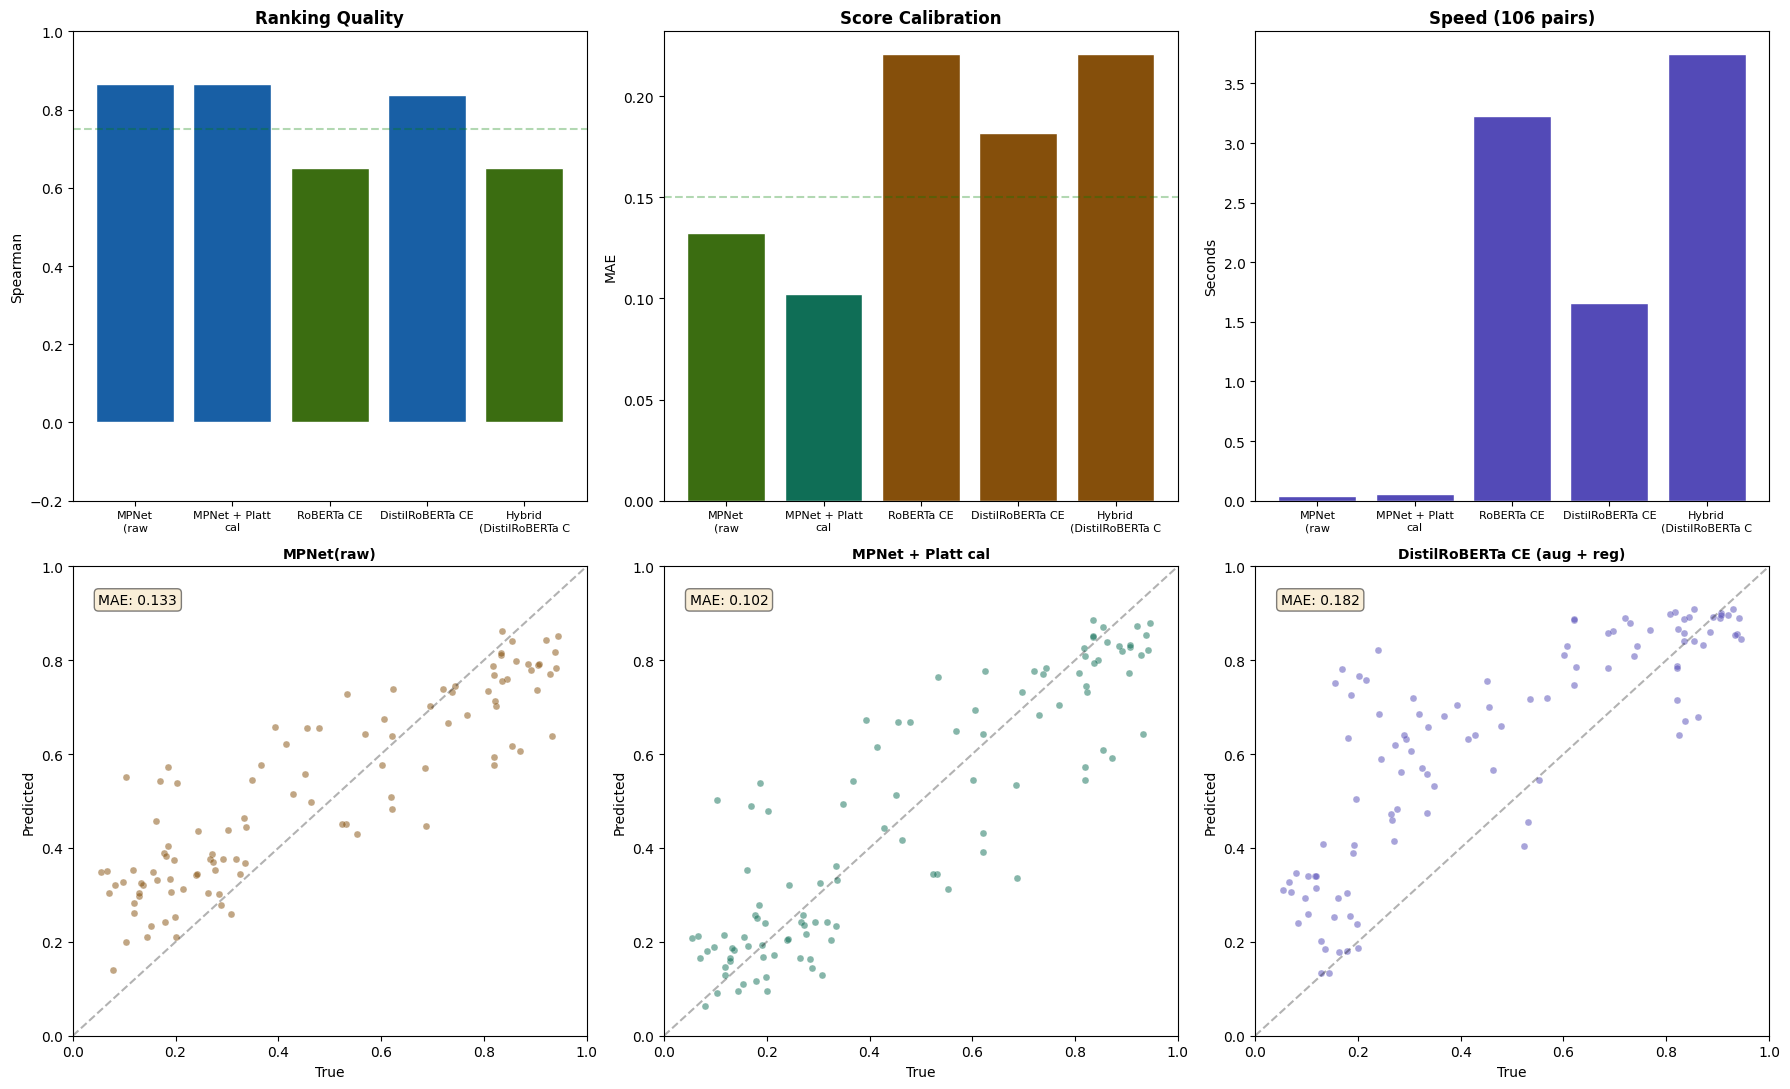

Saved: production_model_comparison.png


In [14]:
import matplotlib.pyplot as plt

key_models = [r for r in all_results if r['name'] in [
    'MPNet (raw, combined loss)', 'MPNet + Platt calibration',
    'RoBERTa CE (aug + reg)', 'DistilRoBERTa CE (aug + reg)',
    all_results[-1]['name']]]

fig, axes = plt.subplots(2, 3, figsize=(18, 11))
names_short = [r['name'].replace(' (aug + reg)','').replace(' (raw, combined loss)','\n(raw)').replace(' calibration','\ncal').replace('Hybrid (MPNet+','Hybrid\n(').replace(')','') for r in key_models]

# Spearman
spears = [r['spearman'] for r in key_models]
colors = ['#185FA5' if s>0.75 else '#3B6D11' if s>0.5 else '#854F0B' if s>0 else '#A32D2D' for s in spears]
axes[0,0].bar(range(len(names_short)), spears, color=colors, edgecolor='white')
axes[0,0].set_xticks(range(len(names_short))); axes[0,0].set_xticklabels(names_short, fontsize=8)
axes[0,0].set_ylabel('Spearman'); axes[0,0].set_title('Ranking Quality', fontweight='bold')
axes[0,0].set_ylim(-0.2,1.0); axes[0,0].axhline(y=0.75, color='green', linestyle='--', alpha=0.3)

# MAE
maes = [r['mae'] for r in key_models]
colors_m = ['#0F6E56' if m<0.12 else '#3B6D11' if m<0.15 else '#854F0B' if m<0.25 else '#A32D2D' for m in maes]
axes[0,1].bar(range(len(names_short)), maes, color=colors_m, edgecolor='white')
axes[0,1].set_xticks(range(len(names_short))); axes[0,1].set_xticklabels(names_short, fontsize=8)
axes[0,1].set_ylabel('MAE'); axes[0,1].set_title('Score Calibration', fontweight='bold')
axes[0,1].axhline(y=0.15, color='green', linestyle='--', alpha=0.3)

# Speed
speeds = [r['speed'] for r in key_models]
axes[0,2].bar(range(len(names_short)), speeds, color='#534AB7', edgecolor='white')
axes[0,2].set_xticks(range(len(names_short))); axes[0,2].set_xticklabels(names_short, fontsize=8)
axes[0,2].set_ylabel('Seconds'); axes[0,2].set_title('Speed (106 pairs)', fontweight='bold')

# Scatter plots: raw MPNet, Platt MPNet, best CE
scatter_targets = ['MPNet (raw, combined loss)', 'MPNet + Platt calibration']
if len(key_models) >= 4: scatter_targets.append(key_models[3]['name'])
scatter_colors = ['#854F0B', '#0F6E56', '#534AB7']
for idx, (mn, mc) in enumerate(zip(scatter_targets, scatter_colors)):
    r = next((res for res in all_results if res['name']==mn), None)
    if r:
        ax = axes[1,idx]
        ax.scatter(r['true_scores'], r['predictions'], alpha=0.5, s=25, c=mc, edgecolors='white', linewidth=0.3)
        ax.plot([0,1],[0,1],'k--',alpha=0.3)
        ax.set_xlabel('True'); ax.set_ylabel('Predicted')
        short = mn.replace(' (raw, combined loss)','(raw)').replace(' calibration',' cal')
        ax.set_title(short, fontweight='bold', fontsize=10)
        ax.set_xlim(0,1); ax.set_ylim(0,1)
        ax.text(0.05, 0.92, f'MAE: {r["mae"]:.3f}', transform=ax.transAxes, fontsize=10,
                bbox=dict(boxstyle='round', facecolor='wheat', alpha=0.5))

plt.tight_layout()
plt.savefig('production_model_comparison.png', dpi=150, bbox_inches='tight')
plt.show()
print("Saved: production_model_comparison.png")


---
## 13. Interactive Testing — Score Any Resume Against Any JD


In [15]:
def score_resume(resume_text, jd_text):
    jd_clean = smart_truncate_jd(jd_text, 350)
    print("\nRESUME-JD MATCH SCORING")
    print("="*60)
    print(f"Resume: {resume_text[:120]}...")
    print(f"JD: {jd_clean[:120]}...")
    print(f"\n{'Model':<35} {'Score':>8} {'Interpretation'}")
    print("-"*65)

    interp = lambda s: "Strong match" if s>=0.70 else "Good match" if s>=0.50 else "Partial match" if s>=0.30 else "Weak match" if s>=0.15 else "No match"

    # MPNet raw
    r_e = model_mpnet.encode([resume_text]); j_e = model_mpnet.encode([jd_clean])
    raw = float(cosine_similarity(r_e, j_e)[0][0])
    cal_s = platt([raw])[0]
    print(f"{'MPNet (raw)':<35} {raw:>8.3f} {interp(raw)}")
    print(f"{'MPNet + Platt':<35} {cal_s:>8.3f} {interp(cal_s)}")

    # Cross-encoders
    for name, model in [('RoBERTa CE', model_roberta), ('DistilRoBERTa CE', model_distil)]:
        s = float(model.predict([(resume_text, jd_clean)])[0])
        s = max(0.0, min(1.0, s))
        print(f"{name:<35} {s:>8.3f} {interp(s)}")

    # Hybrid
    h = hybrid.score_single(resume_text, jd_clean)
    print(f"{'Hybrid':<35} {h:>8.3f} {interp(h)}")

# Demo
for mt in ['strong', 'hard_negative', 'weak']:
    sample = ext_test[ext_test['match_type']==mt].iloc[0]
    print(f"\n\n{'='*60}")
    print(f"TEST: {mt.upper()} (true: {sample['score']:.3f}) | {sample['industry']}")
    score_resume(sample['resume'], sample['jd'])




TEST: STRONG (true: 0.818) | Sales / Business Development

RESUME-JD MATCH SCORING
Resume: Lauren Singh
Salt Lake City, UT | lauren.singh@outlook.com | (638) 293-2140

PROFESSIONAL SUMMARY
Director of Sales with...
JD: Our sales team is committed to customer centricity by focusing on understanding and meeting the uniq c partnerships. By ...

Model                                  Score Interpretation
-----------------------------------------------------------------
MPNet (raw)                            0.787 Strong match
MPNet + Platt                          0.827 Strong match
RoBERTa CE                             0.840 Strong match
DistilRoBERTa CE                       0.902 Strong match
Hybrid                                 0.840 Strong match


TEST: HARD_NEGATIVE (true: 0.239) | Cybersecurity

RESUME-JD MATCH SCORING
Resume: Kenji Anderson
Nashville, TN | kenji.anderson@gmail.com | (255) 789-2612

PROFESSIONAL SUMMARY
Site Reliability Engineer...
JD: Detection Engineer Locati

In [16]:
# ============================================================
# Your own resume test — paste and uncomment
# ============================================================

my_resume = """
[PASTE YOUR RESUME HERE]
"""

my_jd = """
[PASTE A JOB DESCRIPTION HERE]
"""

# Uncomment to run:
# score_resume(my_resume.strip(), my_jd.strip())


---
## 14. Save Models and Results

In [17]:
with open('models/platt_calibrator.pkl', 'wb') as f: pickle.dump(platt, f)
with open('models/iso_calibrator.pkl', 'wb') as f: pickle.dump(iso_cal, f)

summary = {
    'training': {'total_pairs': len(df), 'augmented': len(aug_df), 'unique_jds': 305,
                 'sources': dict(Counter(df['source'])) if 'source' in df.columns else {}},
    'evaluation': {'calibration_set': len(ext_cal), 'final_test': len(ext_test)},
    'results': {r['name']: {'spearman': round(r['spearman'],4), 'mae': round(r['mae'],4)}
                for r in all_results}
}
with open('models/production_results.json', 'w') as f: json.dump(summary, f, indent=2)

print("Models saved:")
print("  models/mpnet-combined-loss/")
print("  models/roberta-ce/")
print("  models/distilroberta-ce/")
print("  models/platt_calibrator.pkl")
print("  models/production_results.json")

print("\nTo push to HuggingFace:")
print("  from huggingface_hub import login; login()")
print("  model_mpnet.save_to_hub('YOUR_USERNAME/resume-matcher-mpnet-v2')")

results_table(all_results, "FINAL PRODUCTION RESULTS")

best = min(all_results, key=lambda r: r['mae'])
print(f"\n\n🎯 PRODUCTION MODEL: {best['name']}")
print(f"   Spearman: {best['spearman']:.4f} | MAE: {best['mae']:.4f}")


Models saved:
  models/mpnet-combined-loss/
  models/roberta-ce/
  models/distilroberta-ce/
  models/platt_calibrator.pkl
  models/production_results.json

To push to HuggingFace:
  from huggingface_hub import login; login()
  model_mpnet.save_to_hub('YOUR_USERNAME/resume-matcher-mpnet-v2')

FINAL PRODUCTION RESULTS
Model                                     Spearman      MAE    Speed
-------------------------------------------------------------------
MPNet (raw, combined loss)                  0.8645   0.1325    0.0s
MPNet + Platt calibration                   0.8645   0.1021    0.1s
MPNet + Isotonic calibration                0.8667   0.1005    0.0s
RoBERTa CE (aug + reg)                      0.6514   0.2209    3.2s
DistilRoBERTa CE (aug + reg)                0.8379   0.1816    1.7s
Hybrid (MPNet+DistilRoBERTa C)              0.6514   0.2209    3.7s

  Best ranking:     MPNet + Isotonic calibration (0.8667)
  Best calibration: MPNet + Isotonic calibration (0.1005)


🎯 PRODUCTION MODEL